<a href="https://colab.research.google.com/github/Mich-088/MAT422/blob/main/HW_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION 1.4



*   1.4.1 - Singular value decomposition
*   1.4.2 - Low-rank matrix approximations
*   1.4.3 - Principal component analysis







# 1.4.1. Singular value decomposition


Singular value decomposition decomoses our matrix A into three matricies.

In SVD we have:
A = U Σ Vᵀ

U is the left singular vectors
S holds the singular values
Vᵀ holds the right singular vectors that are transposed



 1.4.1. SINGULAR VALUE DECOMPOSITION


A = 

[[ 3.   4.   1. ]
 [ 1.   2.   0. ]
 [ 3.   4.3  0. ]
 [ 0.   4.  -2. ]]


U =  

[[-0.5905  0.4479  0.5942]
 [-0.2689  0.0033  0.2228]
 [-0.6263  0.1804 -0.7584]
 [-0.4321 -0.8757  0.1485]]




...

---------------
True
---------------



Does U have orthonormal columns?  (T/F?)

---------------
True
---------------



Is V orthogonal?  (T/F?)

---------------
True
---------------


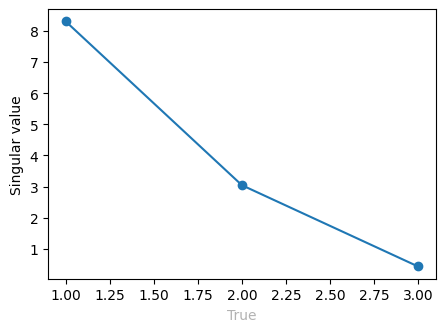

In [69]:
# HW 1.4
# 1.4.1. Singular value decomposition
# 1.4.2. Low-rank matrix approximations
# 1.4.3. Principal component analysis

#======================================================================

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.set_printoptions(precision=4, suppress=True)

A = np.array([
    [3,4,1],
    [1,2,0],
    [3,4.3,0],
    [0,4,-2],
], dtype = float)

display(Markdown("\n 1.4.1. SINGULAR VALUE DECOMPOSITION"))

print("===================================================================")
display(Markdown("\nA = "))
print(A)

print("===================================================================")
# Computing Singular Value Decomposition:
U, S, VT = np.linalg.svd(A, full_matrices = False) # does not return Σ directly
                                                   # S = one-dimentional array containing the singular valus
                                                   # need to change ti diagonal matrix Σ wiht Sigma = np.diag(S)
display(Markdown("U =  "))
print(U)
print("\n")

display(Markdown("S = "))
print(S)
print("\n")

display(Markdown("V^(T) = "))
print(VT)

print("===================================================================")

# Converting to diagonal matrix:

Sigma = np.diag(S)

display(Markdown("\nSigma ="))
print(Sigma)

print("\n")

# Reconstructed A :
A_reconstructed = U @ Sigma @ VT
display(Markdown("\nU @ Sigma @ V^(T) ="))
print(A_reconstructed)
print("\nReconstruction error ||A-A Sigma V^(T)||_f = ")
print(np.linalg.norm(A - A_reconstructed, ord="fro"))

print("===================================================================")

# Make sure recunstructed matrix equals matrix A
display(Markdown("\nDoes U @ Sigma @ V^(T) reconstruct matrix A?  (T/F?)"))
print("---------------")
print(np.allclose(A, A_reconstructed))  # (T/F?)
print("---------------")

# U has orthonormal columns?
display(Markdown("\nDoes U have orthonormal columns?  (T/F?)"))
print("---------------")
print(np.allclose(U.T @ U, np.eye(U.shape[1])))
print("---------------")

# V is orthogonal?
display(Markdown("\nIs V orthogonal?  (T/F?)"))
print("---------------")
print(np.allclose(VT @ VT.T, np.eye(VT.shape[0])))  # (T/F?)
print("---------------")

# Graph
print("===================================================================")

plt.figure(figsize=(5, 3.5))
plt.plot(
    np.arange(1, len(S) + 1),
    S,
    marker = "o"
)

plt.xlabel("Index")
plt.ylabel("Singular value")
plt.xlabel("Singular values of A")
plt.xlabel(True, alpha=0.3)
plt.show()
print("===================================================================")








# 1.4.2 Low-Rank Matrix Approximations


Low-Rank Matrix Approximations allow us to reduce a large matrix to a product of smaller matrices while keeping the details of important patterns.

Instead of storing m x n values, we have: k(m + n) values

As k increases, approximation error decreases, getting us closer and closer to the rull rank where the approximation gets closer and closer to the original matrix.


Rank-1 approximation A_1 =

[[ 2.315  4.324 -0.162]
 [ 1.054  1.968 -0.074]
 [ 2.455  4.585 -0.171]
 [ 1.694  3.164 -0.118]]
Rank of A_1 = 1
Rank-1 approximation error = 3.074100913815777
__________________________________________________



Rank-2 approximation A_2 =

[[ 3.16   3.908  0.823]
 [ 1.06   1.965 -0.066]
 [ 2.795  4.418  0.225]
 [ 0.04   3.977 -2.044]]
Rank of A_2 = 2
Rank-2 approximation error = 0.4303992412166703
__________________________________________________



Rank-3 approximation A_3 =

[[ 3.   4.   1. ]
 [ 1.   2.  -0. ]
 [ 3.   4.3 -0. ]
 [ 0.   4.  -2. ]]
Rank of A_3 = 3
Rank-3 approximation error = 4.0870694009274595e-15
__________________________________________________


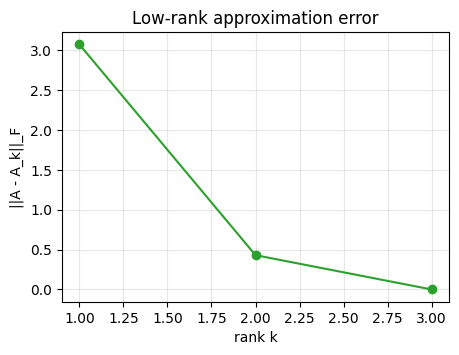

In [73]:
#1.4.2 Low-rank matrix approximations

errors = []

for k in range(1, len(S) +1):
  # keeping the first K ingular vectors/values
  U_k = U[:, :k]
  S_k = S[:k]
  VT_k = VT[:k, :]

  Sigma_k = np.diag(S_k)

  # Constructing rank-k approximation:
  A_k = U_k @ Sigma_k @ VT_k

  # Calc Frobenius error:
  error = np.linalg.norm(A - A_k, ord = "fro")
  errors.append(error)

  display(Markdown(f"\nRank-{k} approximation A_{k} ="))
  print(np.round(A_k, 3))
  print(f"Rank of A_{k} =", np.linalg.matrix_rank(A_k))
  print(f"Rank-{k} approximation error =", error)
  print("__________________________________________________")

  # Graph:
plt.figure(figsize=(5, 3.5))

plt.plot(
    np.arange(1, len(errors) + 1),
    errors,
    marker="o",
    color="tab:green"
)

plt.xlabel("rank k")
plt.ylabel("||A - A_k||_F")
plt.title("Low-rank approximation error")
plt.grid(True, alpha=0.3)
plt.show()

# 1.4.3 Principal component analysis

Here, to execute the principle analysis process, we need to:
- center the data
- find the covariance of the matrix
- find the eigenvalues and eigenvectors
-
- project onto principlr components


Data Set: 

[[1.5 2.4]
 [1.  1. ]
 [2.3 1. ]
 [1.7 0.9]
 [2.7 2.3]
 [1.9 0.9]
 [1.9 1.9]
 [0.6 1. ]
 [0.4 0.7]
 [2.1 2.2]
 [2.5 2. ]
 [1.3 1.5]
 [0.8 0.6]
 [2.8 2.6]
 [1.6 1.3]
 [2.2 1.8]
 [0.9 1.2]
 [1.4 1.8]
 [2.6 1.7]
 [3.  2.8]
 [0.5 0.9]
 [1.8 1.6]
 [2.4 2.5]
 [1.1 0.8]
 [2.9 2.1]
 [1.2 1.4]
 [2.  1.5]
 [0.7 0.5]
 [2.6 2.7]
 [1.7 2. ]]
__________________________________________________
Mean =
[1.7367 1.5867]
Cenetred data =
[[-0.2367  0.8133]
 [-0.7367 -0.5867]
 [ 0.5633 -0.5867]
 [-0.0367 -0.6867]
 [ 0.9633  0.7133]
 [ 0.1633 -0.6867]
 [ 0.1633  0.3133]
 [-1.1367 -0.5867]
 [-1.3367 -0.8867]
 [ 0.3633  0.6133]
 [ 0.7633  0.4133]
 [-0.4367 -0.0867]
 [-0.9367 -0.9867]
 [ 1.0633  1.0133]
 [-0.1367 -0.2867]
 [ 0.4633  0.2133]
 [-0.8367 -0.3867]
 [-0.3367  0.2133]
 [ 0.8633  0.1133]
 [ 1.2633  1.2133]
 [-1.2367 -0.6867]
 [ 0.0633  0.0133]
 [ 0.6633  0.9133]
 [-0.6367 -0.7867]
 [ 1.1633  0.5133]
 [-0.5367 -0.1867]
 [ 0.2633 -0.0867]
 [-1.0367 -1.0867]
 [ 0.8633  1.1133]
 [-0.0367  0.4133]]
________


Covarience matrix = 

[[0.5927 0.404 ]
 [0.404  0.4557]]
__________________________________________________



Eigenvalues =

[0.1145 0.9339]



Eigenvectors =

[[ 0.6453 -0.764 ]
 [-0.764  -0.6453]]
__________________________________________________
Sorted eigenvalues =
[0.9339 0.1145]
Sorted eigenvectors =
[[-0.764   0.6453]
 [-0.6453 -0.764 ]]
__________________________________________________
First principle component: 
[-0.764  -0.6453]
Second principle component: 
[ 0.6453 -0.764 ]
PCA coordinates
[[-0.344  -0.7741]
 [ 0.9413 -0.0272]
 [-0.0518  0.8117]
 [ 0.4711  0.5009]
 [-1.1962  0.0766]
 [ 0.3183  0.63  ]
 [-0.327  -0.134 ]
 [ 1.2469 -0.2853]
 [ 1.5933 -0.1851]
 [-0.6733 -0.2341]
 [-0.8499  0.1768]
 [ 0.3895 -0.2156]
 [ 1.3522  0.1494]
 [-1.4662 -0.088 ]
 [ 0.2894  0.1308]
 [-0.4916  0.136 ]
 [ 0.8887 -0.2445]
 [ 0.1195 -0.3802]
 [-0.7327  0.4705]
 [-1.7481 -0.1118]
 [ 1.3878 -0.2734]
 [-0.057   0.0307]
 [-1.0961 -0.2697]
 [ 0.994   0.1902]
 [-1.22    0.3585]
 [ 0.5304 -0.2037]
 [-0.1453  0.2361]
 [ 1.4932  0.1612]
 [-1.3779 -0.2935]
 [-0.2387 -0.3394]]
Explained variance ratio =
[0.8908 0.1092]
______________________________________

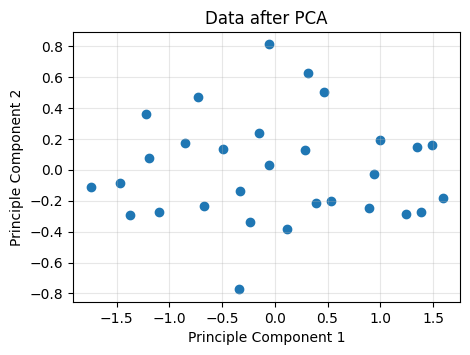

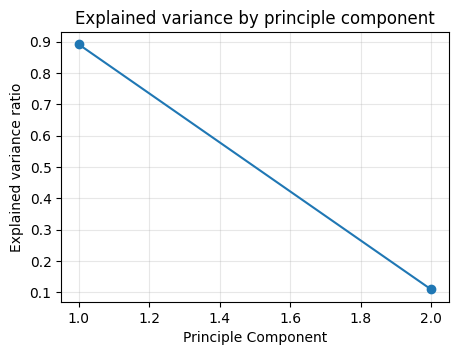

In [71]:
#1.4.3 Principle component analysis

X = np.array([
    [1.5, 2.4],
    [1.0, 1.0],
    [2.3, 1.0],
    [1.7, 0.9],
    [2.7, 2.3],
    [1.9, 0.9],
    [1.9, 1.9],
    [0.6, 1.0],
    [0.4, 0.7],
    [2.1, 2.2],
    [2.5, 2.0],
    [1.3, 1.5],
    [0.8, 0.6],
    [2.8, 2.6],
    [1.6, 1.3],
    [2.2, 1.8],
    [0.9, 1.2],
    [1.4, 1.8],
    [2.6, 1.7],
    [3.0, 2.8],
    [0.5, 0.9],
    [1.8, 1.6],
    [2.4, 2.5],
    [1.1, 0.8],
    [2.9, 2.1],
    [1.2, 1.4],
    [2.0, 1.5],
    [0.7, 0.5],
    [2.6, 2.7],
    [1.7, 2.0],
], dtype=float)

display(Markdown("\nData Set: "))
print(X)

# Mean and centering the data:
print("__________________________________________________")
mean = np.mean(X, axis = 0)
X_centered = X - mean
print("Mean =")
print(mean)
print("Cenetred data =")
print(X_centered)

print("__________________________________________________")
# Finding Covariance of the data:
covariance_matrix = np.cov(X_centered, rowvar = False)
display(Markdown("\nCovarience matrix = "))
print(covariance_matrix)
print("__________________________________________________")

# Findind Eigenvalues & Eigenvectors:
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
display(Markdown("\nEigenvalues ="))
print(eigenvalues)
display(Markdown("\nEigenvectors ="))
print(eigenvectors)

print("__________________________________________________")
indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

print("Sorted eigenvalues =")
print(eigenvalues)
print("Sorted eigenvectors =")
print(eigenvectors)
print("__________________________________________________")

# Finding first and second Principle components:
PC1 = eigenvectors[:, 0]
PC2 = eigenvectors[:, 1]
print("First principle component: ")
print(PC1)
print("Second principle component: ")
print(PC2)

# Projecting data onto the PCs:
X_PCA = X_centered @ eigenvectors
print("PCA coordinates")
print(X_PCA)

# variance = eigenvals of the covariance matrix for a component
# explained variance ratio = relative percentage or proportion of the total variance by a component
# = Div a component's variance by sum ov all variances
explained_var_ratio = eigenvalues / np.sum(eigenvalues)
print("Explained variance ratio =")
print (explained_var_ratio)
print("__________________________________________________")

# Graph:
plt.figure(figsize = (5,3.5))
plt.scatter(X_PCA[:, 0], X_PCA[:, 1])
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.title("Data after PCA")
plt.grid(True, alpha = 0.3)
plt.show()

plt.figure(figsize = (5, 3.5))
plt.plot(
    np.arange(1, len(eigenvalues) + 1),
    explained_var_ratio,
    marker = "o"
)

plt.xlabel("Principle Component")
plt.ylabel("Explained variance ratio")
plt.title("Explained variance by principle component")
plt.grid(True, alpha = 0.3)
plt.show()



Data Set: 

[[1.5 2.4]
 [1.  1. ]
 [2.3 1. ]
 [1.7 0.9]
 [2.7 2.3]
 [1.9 0.9]
 [1.9 1.9]
 [0.6 1. ]
 [0.4 0.7]
 [2.1 2.2]
 [2.5 2. ]
 [1.3 1.5]
 [0.8 0.6]
 [2.8 2.6]
 [1.6 1.3]
 [2.2 1.8]
 [0.9 1.2]
 [1.4 1.8]
 [2.6 1.7]
 [3.  2.8]
 [0.5 0.9]
 [1.8 1.6]
 [2.4 2.5]
 [1.1 0.8]
 [2.9 2.1]
 [1.2 1.4]
 [2.  1.5]
 [0.7 0.5]
 [2.6 2.7]
 [1.7 2. ]]
__________________________________________________
Mean =
[1.7367 1.5867]
Cenetred data =
[[-0.2367  0.8133]
 [-0.7367 -0.5867]
 [ 0.5633 -0.5867]
 [-0.0367 -0.6867]
 [ 0.9633  0.7133]
 [ 0.1633 -0.6867]
 [ 0.1633  0.3133]
 [-1.1367 -0.5867]
 [-1.3367 -0.8867]
 [ 0.3633  0.6133]
 [ 0.7633  0.4133]
 [-0.4367 -0.0867]
 [-0.9367 -0.9867]
 [ 1.0633  1.0133]
 [-0.1367 -0.2867]
 [ 0.4633  0.2133]
 [-0.8367 -0.3867]
 [-0.3367  0.2133]
 [ 0.8633  0.1133]
 [ 1.2633  1.2133]
 [-1.2367 -0.6867]
 [ 0.0633  0.0133]
 [ 0.6633  0.9133]
 [-0.6367 -0.7867]
 [ 1.1633  0.5133]
 [-0.5367 -0.1867]
 [ 0.2633 -0.0867]
 [-1.0367 -1.0867]
 [ 0.8633  1.1133]
 [-0.0367  0.4133]]
________


Covarience matrix = 

[[0.5927 0.404 ]
 [0.404  0.4557]]
__________________________________________________



Eigenvalues =

[0.1145 0.9339]



Eigenvectors =

[[ 0.6453 -0.764 ]
 [-0.764  -0.6453]]
__________________________________________________
Sorted eigenvalues =
[0.9339 0.1145]
Sorted eigenvectors =
[[-0.764   0.6453]
 [-0.6453 -0.764 ]]
__________________________________________________
First principle component: 
[-0.764  -0.6453]
Second principle component: 
[ 0.6453 -0.764 ]
PCA coordinates
[[-0.344  -0.7741]
 [ 0.9413 -0.0272]
 [-0.0518  0.8117]
 [ 0.4711  0.5009]
 [-1.1962  0.0766]
 [ 0.3183  0.63  ]
 [-0.327  -0.134 ]
 [ 1.2469 -0.2853]
 [ 1.5933 -0.1851]
 [-0.6733 -0.2341]
 [-0.8499  0.1768]
 [ 0.3895 -0.2156]
 [ 1.3522  0.1494]
 [-1.4662 -0.088 ]
 [ 0.2894  0.1308]
 [-0.4916  0.136 ]
 [ 0.8887 -0.2445]
 [ 0.1195 -0.3802]
 [-0.7327  0.4705]
 [-1.7481 -0.1118]
 [ 1.3878 -0.2734]
 [-0.057   0.0307]
 [-1.0961 -0.2697]
 [ 0.994   0.1902]
 [-1.22    0.3585]
 [ 0.5304 -0.2037]
 [-0.1453  0.2361]
 [ 1.4932  0.1612]
 [-1.3779 -0.2935]
 [-0.2387 -0.3394]]
Explained variance ratio =
[0.8908 0.1092]
______________________________________

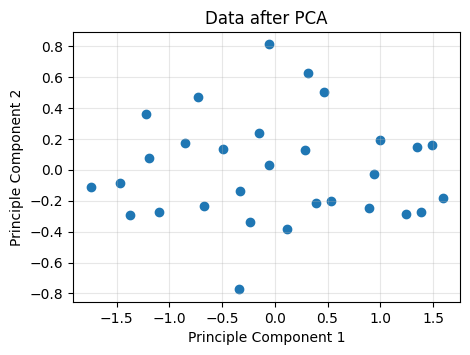

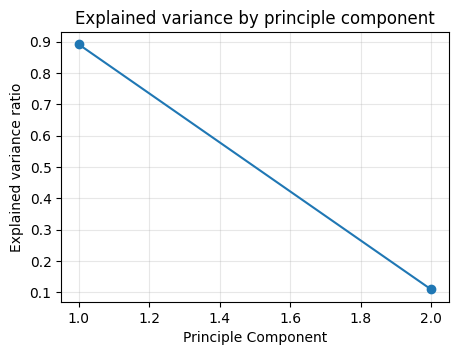

In [72]:
#1.4.3 Principle component analysis

X = np.array([
    [1.5, 2.4],
    [1.0, 1.0],
    [2.3, 1.0],
    [1.7, 0.9],
    [2.7, 2.3],
    [1.9, 0.9],
    [1.9, 1.9],
    [0.6, 1.0],
    [0.4, 0.7],
    [2.1, 2.2],
    [2.5, 2.0],
    [1.3, 1.5],
    [0.8, 0.6],
    [2.8, 2.6],
    [1.6, 1.3],
    [2.2, 1.8],
    [0.9, 1.2],
    [1.4, 1.8],
    [2.6, 1.7],
    [3.0, 2.8],
    [0.5, 0.9],
    [1.8, 1.6],
    [2.4, 2.5],
    [1.1, 0.8],
    [2.9, 2.1],
    [1.2, 1.4],
    [2.0, 1.5],
    [0.7, 0.5],
    [2.6, 2.7],
    [1.7, 2.0],
], dtype=float)

display(Markdown("\nData Set: "))
print(X)

# Mean and centering the data:
print("__________________________________________________")
mean = np.mean(X, axis = 0)
X_centered = X - mean
print("Mean =")
print(mean)

print("Cenetred data =")
print(X_centered)

print("__________________________________________________")
# Finding Covariance of the data:
covariance_matrix = np.cov(X_centered, rowvar = False)
display(Markdown("\nCovarience matrix = "))
print(covariance_matrix)
print("__________________________________________________")

# Findind Eigenvalues & Eigenvectors:
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
display(Markdown("\nEigenvalues ="))
print(eigenvalues)
display(Markdown("\nEigenvectors ="))
print(eigenvectors)

print("__________________________________________________")
indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

print("Sorted eigenvalues =")
print(eigenvalues)
print("Sorted eigenvectors =")
print(eigenvectors)
print("__________________________________________________")

# Finding first and second Principle components:
PC1 = eigenvectors[:, 0]
PC2 = eigenvectors[:, 1]
print("First principle component: ")
print(PC1)
print("Second principle component: ")
print(PC2)

# Projecting data onto the PCs:
X_PCA = X_centered @ eigenvectors
print("PCA coordinates")
print(X_PCA)

# variance = eigenvals of the covariance matrix for a component
# explained variance ratio = relative percentage or proportion of the total variance by a component
# = Div a component's variance by sum ov all variances
explained_var_ratio = eigenvalues / np.sum(eigenvalues)
print("Explained variance ratio =")
print (explained_var_ratio)
print("__________________________________________________")

# Graph:
plt.figure(figsize = (5,3.5))
plt.scatter(X_PCA[:, 0], X_PCA[:, 1])
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.title("Data after PCA")
plt.grid(True, alpha = 0.3)
plt.show()

plt.figure(figsize = (5, 3.5))
plt.plot(
    np.arange(1, len(eigenvalues) + 1),
    explained_var_ratio,
    marker = "o"
)

plt.xlabel("Principle Component")
plt.ylabel("Explained variance ratio")
plt.title("Explained variance by principle component")
plt.grid(True, alpha = 0.3)
plt.show()


In the explained variance ratio we have for this data set, PC1 contains about 0.89 or 89% of the variation in the data and PC2 contains about 0.11 or 11% of the variation in the data.